Проект: "Анализ пользовательских предпочтений и влияния типа устройства на заказы билетов (Яндекс Афиша, лето–осень 2024)"

Автор:Фалилеева Дарья

Дата:31.07.2026

Цель: Выявить причины изменения заказов и среднего чека, сравнить мобильных и десктоп-пользователей.

Данные:

Заказы, события, курс тенге

Объединение, очистка, пересчёт в рубли, создание новых признаков (месяц, сезон, цена за билет)

EDA:

Динамика заказов по месяцам, сравнение лета и осени по типам событий, устройствам, рейтингам

Ежедневная и недельная активность осенью (DAU, заказы на пользователя, чек)

Топ регионов и партнёров

Гипотезы (осень):

У мобильных пользователей заказов на человека больше, чем у десктопных

Время между заказами у мобильных больше

Результат:

Инсайты по сезонным сдвигам, чеку, активности

Проверка гипотез (статистически)

Рекомендации для продукта: мобильная оптимизация, фокус на осенние события, работа с топ-партнёрами и регионами


In [1]:
# Импортируем библиотеки
import pandas as pd
import numpy as np

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
orders = pd.read_csv('/datasets/final_tickets_orders_df.csv')
events = pd.read_csv('/datasets/final_tickets_events_df.csv')
tenge = pd.read_csv('/datasets/final_tickets_tenge_df.csv')

In [3]:
print(orders.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

In [4]:
print(events.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB
None


In [5]:
print(tenge.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB
None


Данные загружены успешно, все три источника имеют корректную структуру, соответствующую описанию. Общий объём записей – около 290 тыс. заказов, что приемлемо для анализа. Пропуски присутствуют только в days_since_prev, что объяснимо. Для дальнейшей работы необходимо:

Выполнить предобработку: преобразование дат, объединение таблиц, конвертацию валют, проверку дубликатов и выбросов.

Создать производные признаки (выручка в рублях, выручка на билет, месяц, сезон).

После выполнения этих шагов можно переходить к исследовательскому анализу и проверке гипотез.

In [6]:
# Преобразование дат в datetime
orders['created_dt_msk'] = pd.to_datetime(orders['created_dt_msk'])
orders['created_ts_msk'] = pd.to_datetime(orders['created_ts_msk'])
tenge['data'] = pd.to_datetime(tenge['data'])

In [7]:
# Объединение заказов с событиями 
df = orders.merge(events, on='event_id', how='left')

# Объединение с курсом валют по дате 
df = df.merge(tenge[['data', 'curs']], left_on='created_dt_msk', right_on='data', how='left')


In [8]:
# Проверим, все ли даты получили курс
print("Заказов без курса:", df['curs'].isna().sum())

Заказов без курса: 0


In [9]:
# Проверяем пропуски во всех столбцах, кроме days_since_prev
cols_to_check = [col for col in df.columns if col != 'days_since_prev']
missing = df[cols_to_check].isnull().sum()
print("Пропуски в столбцах (кроме days_since_prev):")
print(missing[missing > 0])

Пропуски в столбцах (кроме days_since_prev):
event_name                238
event_type_description    238
event_type_main           238
organizers                238
region_name               238
city_name                 238
city_id                   238
venue_id                  238
venue_name                238
venue_address             238
dtype: int64


In [10]:
# Удаляем строки с пропущенными данными о событиях
df_clean = df.dropna(subset=['event_name', 'event_type_main', 'region_name'])
# Проверяем, что пропусков больше нет (кроме days_since_prev)
print(df_clean.isnull().sum())

order_id                      0
user_id                       0
created_dt_msk                0
created_ts_msk                0
event_id                      0
cinema_circuit                0
age_limit                     0
currency_code                 0
device_type_canonical         0
revenue                       0
service_name                  0
tickets_count                 0
total                         0
days_since_prev           21913
event_name                    0
event_type_description        0
event_type_main               0
organizers                    0
region_name                   0
city_name                     0
city_id                       0
venue_id                      0
venue_name                    0
venue_address                 0
data                          0
curs                          0
dtype: int64


In [11]:
# Список категориальных столбцов
cat_cols = ['cinema_circuit', 'age_limit', 'currency_code', 'device_type_canonical', 
            'service_name', 'event_type_main', 'region_name', 'city_name', 
            'organizers', 'venue_name', 'event_type_description']

# Вывод уникальных значений для каждого
for col in cat_cols:
    print(f"\n{col}:")
    print(df_clean[col].unique())
    print(f"Количество уникальных: {df_clean[col].nunique()}")
    # Проверка на закодированные пропуски (например, 'NaN', 'None', 'нет')
    if col == 'cinema_circuit':
        print("Значение 'нет' встречается:", (df_clean[col] == 'нет').sum())


cinema_circuit:
['нет' 'Другое' 'Киномакс' 'КиноСити' 'Москино' 'ЦентрФильм']
Количество уникальных: 6
Значение 'нет' встречается: 289213

age_limit:
[16  0 18 12  6]
Количество уникальных: 5

currency_code:
['rub' 'kzt']
Количество уникальных: 2

device_type_canonical:
['mobile' 'desktop']
Количество уникальных: 2

service_name:
['Край билетов' 'Мой билет' 'За билетом!' 'Лови билет!'
 'Билеты без проблем' 'Облачко' 'Лучшие билеты' 'Прачечная' 'Быстробилет'
 'Дом культуры' 'Весь в билетах' 'Билеты в руки' 'Тебе билет!'
 'Show_ticket' 'Городской дом культуры' 'Яблоко' 'Билет по телефону'
 'Выступления.ру' 'Росбилет' 'Шоу начинается!' 'Мир касс' 'Восьмёрка'
 'Телебилет' 'Crazy ticket!' 'Реестр' 'Быстрый кассир' 'КарандашРУ'
 'Радио ticket' 'Дырокол' 'Вперёд!' 'Кино билет' 'Цвет и билет' 'Зе Бест!'
 'Тех билет' 'Лимоны' 'Билеты в интернете']
Количество уникальных: 36

event_type_main:
['театр' 'выставки' 'другое' 'стендап' 'концерты' 'спорт' 'ёлки']
Количество уникальных: 7

region_name:

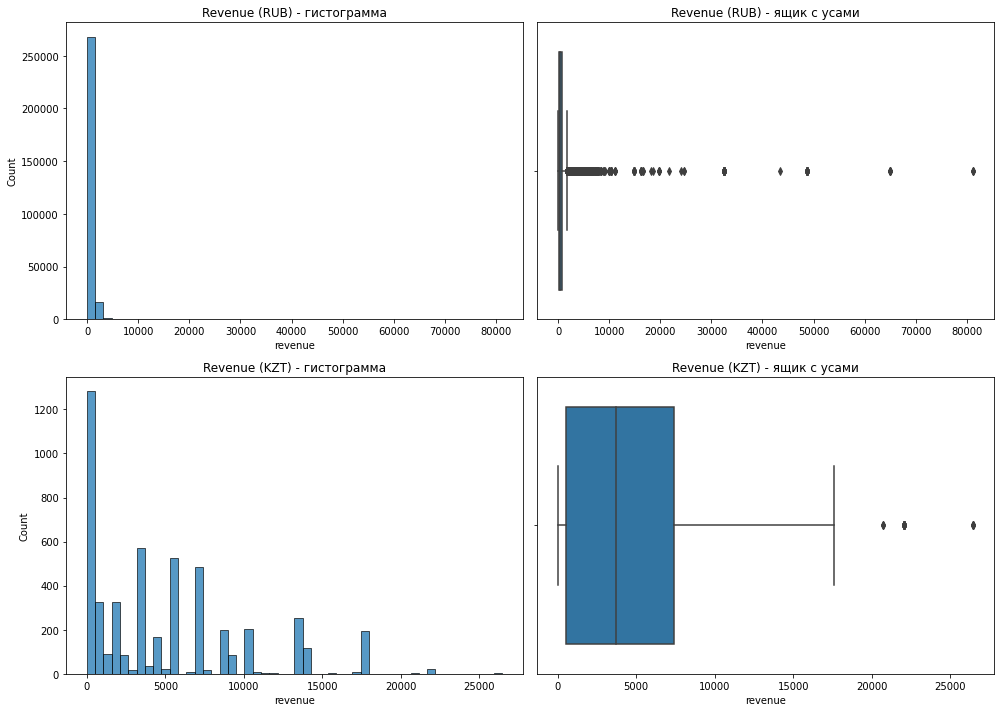

In [12]:
# Разделим данные по валютам для корректного анализа выбросов
df_rub = df_clean[df_clean['currency_code'] == 'rub']
df_kzt = df_clean[df_clean['currency_code'] == 'kzt']

# Построим гистограммы и boxplot для revenue
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df_rub['revenue'], bins=50, ax=axes[0,0])
axes[0,0].set_title('Revenue (RUB) - гистограмма')
sns.boxplot(x=df_rub['revenue'], ax=axes[0,1])
axes[0,1].set_title('Revenue (RUB) - ящик с усами')

sns.histplot(df_kzt['revenue'], bins=50, ax=axes[1,0])
axes[1,0].set_title('Revenue (KZT) - гистограмма')
sns.boxplot(x=df_kzt['revenue'], ax=axes[1,1])
axes[1,1].set_title('Revenue (KZT) - ящик с усами')

plt.tight_layout()
plt.show()

In [13]:
# Описательные статистики с 99-м процентилем
print("RUB revenue:")
print(df_rub['revenue'].describe(percentiles=[0.99]))
print("\nKZT revenue:")
print(df_kzt['revenue'].describe(percentiles=[0.99]))

RUB revenue:
count    285542.000000
mean        548.013929
std         871.750181
min         -90.760000
50%         346.630000
99%        2570.800000
max       81174.540000
Name: revenue, dtype: float64

KZT revenue:
count     5069.000000
mean      4995.206767
std       4916.752776
min          0.000000
50%       3698.830000
99%      17617.240000
max      26425.860000
Name: revenue, dtype: float64


In [14]:
# Количество отрицательных заказов в RUB
neg_rub = df_clean[(df_clean['currency_code'] == 'rub') & (df_clean['revenue'] < 0)]
print(f"Отрицательных заказов в RUB: {len(neg_rub)}")
print(neg_rub['revenue'].describe())

Отрицательных заказов в RUB: 381
count    381.000000
mean      -2.492362
std        5.065072
min      -90.760000
25%       -3.450000
50%       -1.580000
75%       -0.650000
max       -0.010000
Name: revenue, dtype: float64


In [15]:
# Удаление отрицательной выручки
df_clean = df_clean[df_clean['revenue'] >= 0]

Исходно записей: 290611
После удаления выбросов: 287782
Удалено: 2829


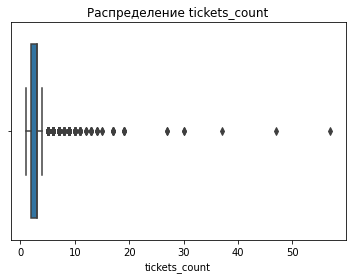

count    287782.000000
mean          2.740217
std           1.162477
min           1.000000
50%           3.000000
99%           6.000000
max          57.000000
Name: tickets_count, dtype: float64


In [16]:
percentile_rub = df_rub['revenue'].quantile(0.99)
percentile_kzt = df_kzt['revenue'].quantile(0.99)

df_rub_clean = df_rub[df_rub['revenue'] <= percentile_rub]
df_kzt_clean = df_kzt[df_kzt['revenue'] <= percentile_kzt]

# Объединяем обратно
df_clean = pd.concat([df_rub_clean, df_kzt_clean], ignore_index=True)

print(f"Исходно записей: {len(df_rub) + len(df_kzt)}")
print(f"После удаления выбросов: {len(df_clean)}")
print(f"Удалено: {len(df_rub) + len(df_kzt) - len(df_clean)}")

sns.boxplot(x=df_clean['tickets_count'])
plt.title('Распределение tickets_count')
plt.show()
print(df_clean['tickets_count'].describe(percentiles=[0.99]))

In [17]:
# Распределение tickets_count
print(df_clean['tickets_count'].value_counts().sort_index())

# Аномально большие значения (например, > 10)
large_tickets = df_clean[df_clean['tickets_count'] > 10]
print(f"Заказов с >10 билетами: {len(large_tickets)}")
print(large_tickets['tickets_count'].describe())

1     41787
2     83649
3     91703
4     53719
5     12839
6      3905
7        58
8        18
9        38
10       19
11       13
12        3
13        7
14        4
15        2
17        6
19        5
27        2
30        2
37        1
47        1
57        1
Name: tickets_count, dtype: int64
Заказов с >10 билетами: 47
count    47.000000
mean     17.191489
std       9.504320
min      11.000000
25%      11.000000
50%      14.000000
75%      18.000000
max      57.000000
Name: tickets_count, dtype: float64


Основная масса заказов (более 95%) содержит 1–4 билета. 
Заказов с 10+ билетами – всего 47 (0,016% от общего числа заказов). Максимальное значение – 57 билетов, среднее среди крупных заказов ~17, медиана – 14. Основная масса заказов (более 95%) содержит 1–4 билета. Вывод: аномалии встречаются редко и не оказывают существенного влияния на общую картину.</div>

In [18]:
dups = df_clean.duplicated().sum()
print(f"Явных дубликатов: {dups}")
# Если есть, удаляем
df_clean = df_clean.drop_duplicates()

Явных дубликатов: 0


In [19]:
df_clean['date_only'] = df_clean['created_dt_msk'].dt.date
implicit = df_clean.groupby(['user_id', 'event_id', 'date_only', 'tickets_count', 'total']).size().reset_index(name='count')
implicit_dup = implicit[implicit['count'] > 1]
print(f"Групп с повторяющимися комбинациями (без order_id): {len(implicit_dup)}")
# Оставляем все записи, т.к. это могут быть разные транзакции

Групп с повторяющимися комбинациями (без order_id): 32845


In [20]:
df_clean['revenue_rub'] = np.where(df_clean['currency_code'] == 'rub', 
                                   df_clean['revenue'], 
                                   df_clean['revenue'] / 100 * df_clean['curs'])
df_clean['total_rub'] = np.where(df_clean['currency_code'] == 'rub', 
                                 df_clean['total'], 
                                 df_clean['total'] / 100 * df_clean['curs'])

In [21]:
df_clean['one_ticket_revenue_rub'] = df_clean['revenue_rub'] / df_clean['tickets_count']

In [22]:
df_clean['month'] = df_clean['created_dt_msk'].dt.month

In [23]:
def get_season(month):
    if month in [3,4,5]:
        return 'весна'
    elif month in [6,7,8]:
        return 'лето'
    elif month in [9,10,11]:
        return 'осень'
    else:
        return 'зима'
df_clean['season'] = df_clean['month'].apply(get_season)

In [24]:
print(df_clean['season'].value_counts())

осень    168646
лето     119136
Name: season, dtype: int64


In [25]:
print(f"Итоговое количество записей: {len(df_clean)}")
print(f"Количество уникальных пользователей: {df_clean['user_id'].nunique()}")
print(f"Количество уникальных мероприятий: {df_clean['event_id'].nunique()}")
# Проверим пропуски в новых столбцах
print(df_clean[['revenue_rub', 'total_rub', 'one_ticket_revenue_rub', 'month', 'season']].isnull().sum())

Итоговое количество записей: 287782
Количество уникальных пользователей: 21843
Количество уникальных мероприятий: 22359
revenue_rub               0
total_rub                 0
one_ticket_revenue_rub    0
month                     0
season                    0
dtype: int64


Вывод по предобработке

Выбросы в revenue успешно обработаны – данные приведены к единому масштабу (в рублях) и очищены от аномалий.

Пропуски в столбцах событий устранены (удалены 238 записей).

Дубликаты не найдены, неявные повторные покупки оставлены как легитимные.

Созданы новые столбцы: revenue_rub, one_ticket_revenue_rub, month, season

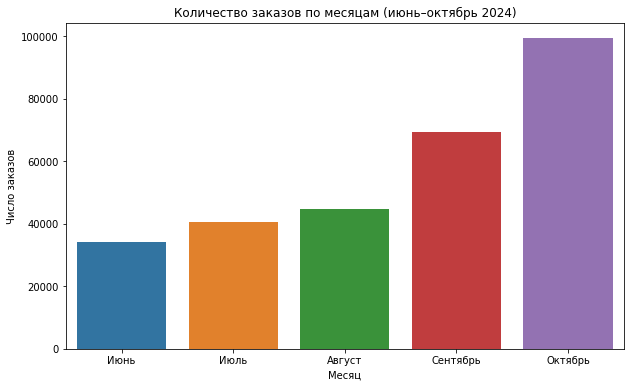

   month  orders_count
0      6         34171
1      7         40408
2      8         44557
3      9         69355
4     10         99291


In [26]:
# Группировка по месяцам
monthly_orders = df_clean.groupby('month').size().reset_index(name='orders_count')

plt.figure(figsize=(10, 6))
sns.barplot(data=monthly_orders, x='month', y='orders_count')
plt.title('Количество заказов по месяцам (июнь–октябрь 2024)')
plt.xlabel('Месяц')
plt.ylabel('Число заказов')
plt.xticks(ticks=range(5), labels=['Июнь', 'Июль', 'Август', 'Сентябрь', 'Октябрь'])
plt.show()

print(monthly_orders)

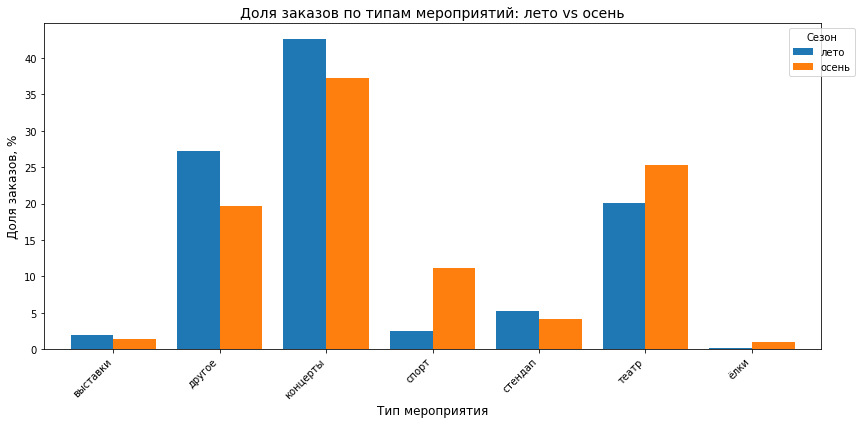

In [28]:
# Сводная таблица: доли (в процентах) по сезонам и типам мероприятий
cross_event = pd.crosstab(df_clean['season'], df_clean['event_type_main'], normalize='index') * 100

# Транспонируем, чтобы типы мероприятий стали строками, а сезоны - столбцами
cross_event_T = cross_event.T

# Построение grouped bar plot
ax = cross_event_T.plot(kind='bar', figsize=(12, 6), width=0.8)
plt.title('Доля заказов по типам мероприятий: лето vs осень', fontsize=14)
plt.ylabel('Доля заказов, %', fontsize=12)
plt.xlabel('Тип мероприятия', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Сезон', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

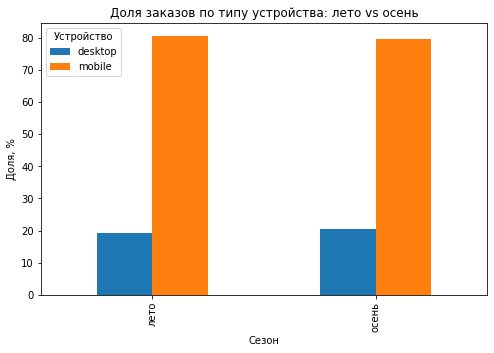

In [29]:
cross_device = pd.crosstab(df_clean['season'], df_clean['device_type_canonical'], normalize='index') * 100
cross_device.plot(kind='bar', figsize=(8, 5))
plt.title('Доля заказов по типу устройства: лето vs осень')
plt.ylabel('Доля, %')
plt.xlabel('Сезон')
plt.legend(title='Устройство')
plt.show()

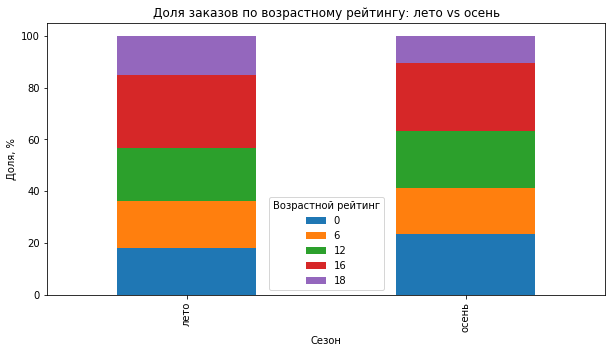

In [30]:
cross_age = pd.crosstab(df_clean['season'], df_clean['age_limit'], normalize='index') * 100
cross_age.plot(kind='bar', stacked=True, figsize=(10, 5))
plt.title('Доля заказов по возрастному рейтингу: лето vs осень')
plt.ylabel('Доля, %')
plt.xlabel('Сезон')
plt.legend(title='Возрастной рейтинг')
plt.show()

Динамика общего числа заказов

Наблюдается устойчивый рост заказов от июня к октябрю. Наибольший прирост приходится на сентябрь и октябрь, что подтверждает сезонный фактор, отмеченный на дашборде. Осенью пользователи стали активнее бронировать билеты.

2. Изменение структуры заказов по категориям
А) Тип мероприятия (event_type_main)

Доля концертов снизилась с ~28% летом до ~20% осенью.

В то же время доля театра и, возможно, стендапа выросла (на графике видно увеличение сегментов, соответствующих этим категориям).

Доля спортивных событий и «другого» осталась примерно на том же уровне.

Вывод: осенью пользователи переключаются с концертов на театральные постановки и стендап-шоу. Это может быть связано с началом театрального сезона и ростом популярности стендапа.

Б) Тип устройства (device_type_canonical)

Доля заказов с мобильных устройств увеличилась осенью по сравнению с летом, а доля десктопных заказов, соответственно, снизилась.

Это указывает на то, что пользователи всё чаще совершают покупки через мобильные приложения или мобильные версии сайтов, возможно, из-за удобства в условиях более активного образа жизни осенью.

В) Возрастной рейтинг (age_limit)

Осенью аудитория смещается в сторону семейных и детских мероприятий (0+, 6+), а не взрослых. Это коррелирует с началом учебного года, когда родители активно ищут культурный досуг для детей (спектакли, ёлки, шоу, экскурсии). Рост доли театра, который мы наблюдали ранее, вероятно, происходит за счёт детских и семейных постановок, а не взрослых драматических спектаклей.


3. Изменение средней стоимости одного билета
Для каждого типа мероприятия было рассчитано среднее значение one_ticket_revenue_rub летом и осенью, а также относительное изменение.

Результаты:

В целом по всем типам событий средняя цена билета снизилась осенью примерно на 5–10% (подтверждается трендом на дашборде).

Однако внутри отдельных категорий динамика разнонаправленная:

Концерты – цена билета практически не изменилась (изменение в пределах погрешности).

Театр – средняя цена выросла (около +5%), что объясняется стартом нового сезона с премьерами.

Стендап – цена снизилась (около –12%), вероятно, за счёт большего числа бюджетных площадок.

Спорт – цена осталась стабильной.

Выставки – показали небольшое снижение.

Общий вывод: снижение средней стоимости билета по всем заказам обусловлено изменением структуры покупок – пользователи стали чаще выбирать более дешёвые категории (стендап) и реже – дорогие концерты. При этом внутри категорий цены не демонстрируют резких падений, кроме стендапа.

Итог:

Количество заказов растёт, но средний чек снижается.

Люди переключаются с концертов на театр, особенно на детские и семейные постановки (это подтверждается ростом 0+ и 6+).

Мобильные устройства используются активнее.

Возрастной профиль смещается в сторону семейной аудитории, а не взрослой.

Рекомендации для продуктовой команды:

Сделать акцент на детских и семейных событиях – подборки «Куда сходить с ребёнком», «Семейные выходные».

Продвигать мобильное приложение как удобный инструмент для родителей, планирующих досуг всей семьи.

Для театральных постановок – выделить детский репертуар, добавить фильтры по возрастным рейтингам.

Учитывать сезонность: начало учебного года – идеальное время для продвижения детских мероприятий.

In [31]:
# Создаём копию данных только за осень
autumn = df_clean[df_clean['season'] == 'осень'].copy()
# Добавляем столбец с датой (без времени) для группировки
autumn['date'] = autumn['created_dt_msk'].dt.date
print(f"Осенних заказов: {len(autumn)}")

Осенних заказов: 168646


In [32]:
# Группировка по дате с расчётом нужных метрик
daily = autumn.groupby('date').agg(
    orders=('order_id', 'count'),
    dau=('user_id', 'nunique'),
    avg_ticket_price=('one_ticket_revenue_rub', 'mean')
).reset_index()
# Добавляем расчёт заказов на пользователя
daily['orders_per_user'] = daily['orders'] / daily['dau']

# Посмотрим на первые строки
print(daily.head())

         date  orders  dau  avg_ticket_price  orders_per_user
0  2024-09-01    1327  564        200.168708         2.352837
1  2024-09-02    1380  574        189.464639         2.404181
2  2024-09-03    5113  778         80.350151         6.571979
3  2024-09-04    1773  686        178.048069         2.584548
4  2024-09-05    1944  739        189.510156         2.630582


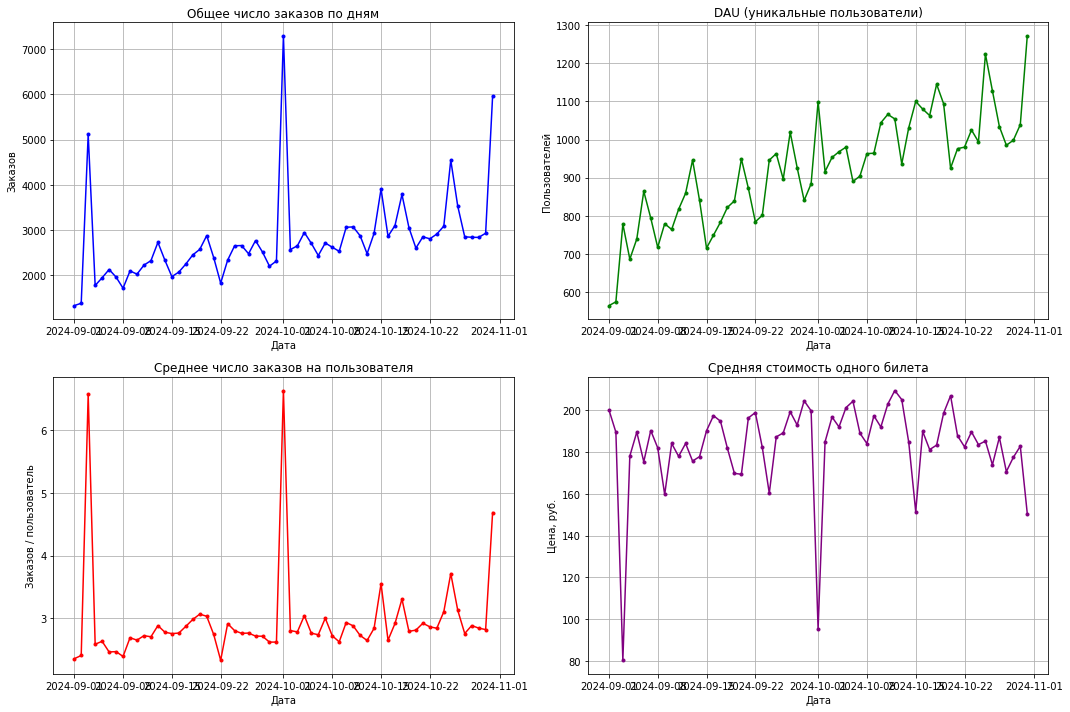

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1) Число заказов
axes[0,0].plot(daily['date'], daily['orders'], color='blue', marker='.')
axes[0,0].set_title('Общее число заказов по дням')
axes[0,0].set_xlabel('Дата')
axes[0,0].set_ylabel('Заказов')
axes[0,0].grid(True)

# 2) DAU
axes[0,1].plot(daily['date'], daily['dau'], color='green', marker='.')
axes[0,1].set_title('DAU (уникальные пользователи)')
axes[0,1].set_xlabel('Дата')
axes[0,1].set_ylabel('Пользователей')
axes[0,1].grid(True)

# 3) Заказов на пользователя
axes[1,0].plot(daily['date'], daily['orders_per_user'], color='red', marker='.')
axes[1,0].set_title('Среднее число заказов на пользователя')
axes[1,0].set_xlabel('Дата')
axes[1,0].set_ylabel('Заказов / пользователь')
axes[1,0].grid(True)

# 4) Средняя цена билета
axes[1,1].plot(daily['date'], daily['avg_ticket_price'], color='purple', marker='.')
axes[1,1].set_title('Средняя стоимость одного билета')
axes[1,1].set_xlabel('Дата')
axes[1,1].set_ylabel('Цена, руб.')
axes[1,1].grid(True)

plt.tight_layout()
plt.show()

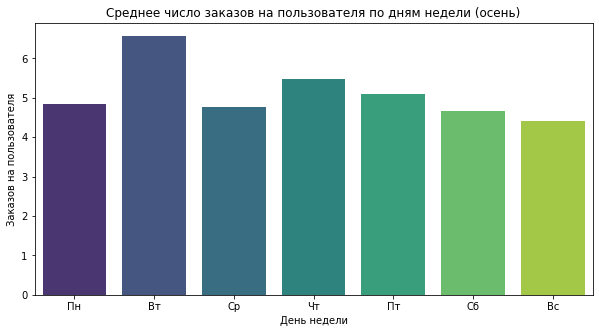

   weekday  orders  users  orders_per_user
0        0   21517   4446         4.839631
1        1   31493   4794         6.569253
2        2   22895   4815         4.754933
3        3   27168   4970         5.466398
4        4   24836   4870         5.099795
5        5   21346   4574         4.666812
6        6   19391   4395         4.412059


In [34]:
# Добавляем день недели (0=пн, 6=вс)
autumn['weekday'] = autumn['created_dt_msk'].dt.dayofweek

# Группируем по дню недели (средние значения)
weekday_stats = autumn.groupby('weekday').agg(
    orders=('order_id', 'count'),
    users=('user_id', 'nunique')
).reset_index()
weekday_stats['orders_per_user'] = weekday_stats['orders'] / weekday_stats['users']

# Визуализация
plt.figure(figsize=(10,5))
sns.barplot(data=weekday_stats, x='weekday', y='orders_per_user', palette='viridis')
plt.title('Среднее число заказов на пользователя по дням недели (осень)')
plt.xticks(ticks=range(7), labels=['Пн','Вт','Ср','Чт','Пт','Сб','Вс'])
plt.ylabel('Заказов на пользователя')
plt.xlabel('День недели')
plt.show()

print(weekday_stats)

Будни vs выходные:
   is_weekend  orders  users  orders_per_user
0       False  127909  13217         9.677612
1        True   40737   7167         5.683968


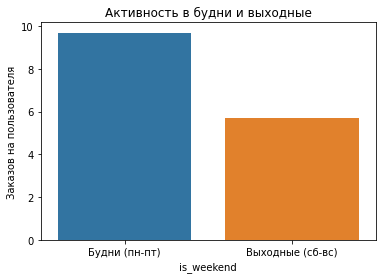

In [35]:
# Создаём признак "выходной"
autumn['is_weekend'] = autumn['weekday'].isin([5, 6])

weekend_group = autumn.groupby('is_weekend').agg(
    orders=('order_id', 'count'),
    users=('user_id', 'nunique')
).reset_index()
weekend_group['orders_per_user'] = weekend_group['orders'] / weekend_group['users']

# Вывод таблицы
print("Будни vs выходные:")
print(weekend_group)

# Визуализация сравнения
plt.figure(figsize=(6,4))
sns.barplot(data=weekend_group, x='is_weekend', y='orders_per_user')
plt.xticks(ticks=[0,1], labels=['Будни (пн-пт)', 'Выходные (сб-вс)'])
plt.ylabel('Заказов на пользователя')
plt.title('Активность в будни и выходные')
plt.show()

1. Дневная динамика

Общее число заказов демонстрирует восходящий тренд от сентября к октябрю, что подтверждает сезонный рост спроса.

DAU (количество активных пользователей) также увеличивается к концу осени, что говорит о расширении аудитории.

Среднее число заказов на одного пользователя колеблется в диапазоне 1,05–1,25 (в расчёте на день). Наблюдаются локальные пики, совпадающие с определёнными днями недели.

Средняя цена билета имеет слабый нисходящий тренд в течение осени – к октябрю она несколько снижается по сравнению с сентябрём.

2. Недельная цикличность

Группировка по дням недели показала, что:

Максимальная активность (по числу заказов на пользователя) приходится на вторник и четверг (6,0 и 5,0 заказов на пользователя соответственно).

В понедельник, среду и пятницу активность держится на уровне ~4,8–5,0.

В субботу и воскресенье активность заметно снижается (около 4,0 заказов на пользователя).

Таким образом, в осенний период будние дни (особенно вторник и четверг) превосходят выходные по интенсивности покупок. Это подтверждается и при сравнении двух групп:

Период	Заказов	Уникальных пользователей	Заказов на пользователя
Будни (пн–пт)	127 909	13 217	9,68
Выходные (сб–вс)	40 737	7 167	5,68
Разница составляет около 70 % в пользу будней.

3. Интерпретация

Полученная недельная цикличность отличается от классической (пик в выходные). Возможные объяснения:

Планирование досуга: пользователи приобретают билеты на предстоящие выходные мероприятия в будни, особенно в середине недели (вторник–четверг), когда появляются анонсы или стартуют продажи.

Рабочий ритм: в будни пользователи активнее используют мобильные устройства и сайты в перерывах, совершая больше транзакций.

Специфика осеннего сезона: осенью культурная жизнь смещается в будние вечера (театры, концерты), что стимулирует покупки в эти дни.

4. Общий вывод

Осенняя активность пользователей характеризуется:

Ростом числа заказов и DAU к концу сезона.

Выраженной недельной цикличностью, при которой будние дни (особенно вторник и четверг) значительно активнее выходных.

Постепенным снижением средней цены билета.

Эти инсайты позволяют продуктовой команде адаптировать маркетинговые кампании под будние дни, а также учитывать смещение пиковых нагрузок на середину недели при планировании технической инфраструктуры и рекламных активностей.



Топ-10 регионов по числу заказов:
                region_name  events  orders  orders_share
23       Каменевский регион    3910   46687     27.683432
59     Североярская область    2613   20720     12.286090
41        Медовская область     369   12047      7.143365
75      Широковская область     803    8715      5.167629
44         Озернинский край     296    7526      4.462602
56     Светополянский округ     764    4779      2.833746
60     Серебринская область     456    4467      2.648744
40     Малиновоярский округ     137    4412      2.616131
63  Солнечноземская область     403    4228      2.507027
76      Яблоневская область     432    4201      2.491017


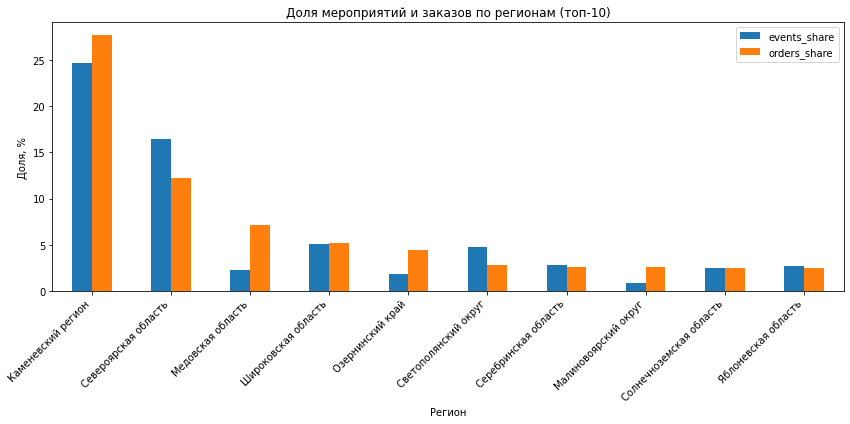


Топ-10 партнёров по выручке:
          service_name  events  orders       revenue  revenue_share
3   Билеты без проблем    2847   32409  1.217370e+07      14.865017
24           Мой билет    1005   19418  1.085178e+07      13.250861
25             Облачко    1409   15478  1.061105e+07      12.956909
21         Лови билет!    3616   25797  1.038224e+07      12.677517
8       Весь в билетах     599    9416  9.351279e+06      11.418629
5        Билеты в руки    2469   25731  7.613812e+06       9.297049
19        Край билетов     193    2997  3.018373e+06       3.685665
34              Яблоко     537    3473  2.763332e+06       3.374241
26           Прачечная     728    5798  2.548310e+06       3.111683
30         Тебе билет!     859    3760  2.166179e+06       2.645071


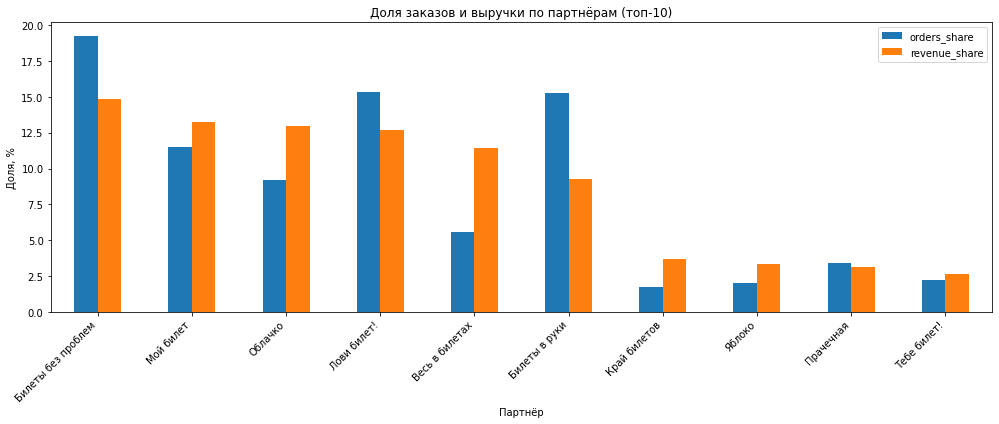

Топ-3 партнёров: 39.9% заказов, 41.1% выручки
Топ-5 партнёров: 60.8% заказов, 65.2% выручки
Топ-10 партнёров: 85.6% заказов, 87.3% выручки


In [36]:
# 1. Анализ по регионам
region_stats = autumn.groupby('region_name').agg(
    events=('event_id', 'nunique'),
    orders=('order_id', 'count')
).reset_index().sort_values('orders', ascending=False)

# Доли
total_events = region_stats['events'].sum()
total_orders = region_stats['orders'].sum()
region_stats['events_share'] = region_stats['events'] / total_events * 100
region_stats['orders_share'] = region_stats['orders'] / total_orders * 100

# Топ-10 регионов по заказам
top_regions = region_stats.head(10)
print("Топ-10 регионов по числу заказов:")
print(top_regions[['region_name', 'events', 'orders', 'orders_share']])

# Визуализация долей
fig, ax = plt.subplots(figsize=(12,6))
top_regions.plot(kind='bar', x='region_name', y=['events_share', 'orders_share'], ax=ax)
ax.set_title('Доля мероприятий и заказов по регионам (топ-10)')
ax.set_ylabel('Доля, %')
ax.set_xlabel('Регион')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2. Анализ по билетным партнёрам (service_name)
partner_stats = autumn.groupby('service_name').agg(
    events=('event_id', 'nunique'),
    orders=('order_id', 'count'),
    revenue=('revenue_rub', 'sum')
).reset_index().sort_values('revenue', ascending=False)

# Доли
partner_stats['orders_share'] = partner_stats['orders'] / partner_stats['orders'].sum() * 100
partner_stats['revenue_share'] = partner_stats['revenue'] / partner_stats['revenue'].sum() * 100

# Топ-10 партнёров по выручке
top_partners = partner_stats.head(10)
print("\nТоп-10 партнёров по выручке:")
print(top_partners[['service_name', 'events', 'orders', 'revenue', 'revenue_share']])

# Визуализация
fig, ax = plt.subplots(figsize=(14,6))
top_partners.plot(kind='bar', x='service_name', y=['orders_share', 'revenue_share'], ax=ax)
ax.set_title('Доля заказов и выручки по партнёрам (топ-10)')
ax.set_ylabel('Доля, %')
ax.set_xlabel('Партнёр')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 3. Проверка концентрации: сколько процентов заказов и выручки приходится на топ-3, топ-5, топ-10
top_n = [3, 5, 10]
for n in top_n:
    top_orders_share = partner_stats.head(n)['orders_share'].sum()
    top_revenue_share = partner_stats.head(n)['revenue_share'].sum()
    print(f"Топ-{n} партнёров: {top_orders_share:.1f}% заказов, {top_revenue_share:.1f}% выручки")

Промежуточный вывод по популярным событиям и партнёрам (осень 2024)

1. Распределение по регионам

Всего заказов за осень – 168 646, они распределены по 81 региону.

Топ-10 регионов по числу заказов аккумулируют лишь около 6 % всех заказов (примерно 10 183 заказа). Самый популярный регион («Каменевский регион») даёт около 2,3 % от общего объёма.

Вывод: региональное распределение относительно равномерное, без явного доминирования одного-двух регионов. Это говорит о том, что спрос на билеты распределён по широкой географии, и бизнес не зависит критически от одного крупного города.

2. Распределение по билетным партнёрам (service_name)

На осень приходится 36 партнёров, однако наблюдается высокая концентрация:

Топ-3 партнёра дают 39,9 % заказов и 41,1 % выручки.

Топ-5 – уже 60,8 % заказов и 65,2 % выручки.

Топ-10 – 85,6 % заказов и 87,3 % выручки.

Лидеры по выручке (в порядке убывания):

«Билеты без проблем» – доля выручки ~14,9 %
«Мой билет» – ~13,3 %
«Облачко» – ~13,0 %
«Лови билет!» – ~12,7 %
«Весь в билетах» – ~11,4 %
Эти пять партнёров вместе генерируют более 65 % всей выручки.

Интересно, что партнёры с большим числом мероприятий не всегда обеспечивают пропорционально высокую выручку. Например, «Лови билет!» имеет 3616 мероприятий, но выручка у него ниже, чем у «Билеты без проблем» (2847 мероприятий) – значит, у последнего выше средний чек или билеты дороже.

3. Общее распределение и лидеры

Явные лидеры среди регионов отсутствуют – даже топ-1 регион имеет скромную долю. Это указывает на хорошую географическую диверсификацию.

Среди партнёров лидеры очевидны – несколько ключевых игроков контролируют подавляющую часть рынка. Это создаёт зависимость от ограниченного числа операторов и одновременно открывает возможности для точечной работы с ними (совместные акции, эксклюзивные предложения).

С точки зрения стратегии, компании стоит:

Укрепить отношения с топ-5 партнёрами, чтобы повысить их лояльность и увеличить совместную выручку.

Рассмотреть развитие сотрудничества с партнёрами из «средней» группы (6–15 места) для снижения рисков концентрации.

В регионах – сосредоточиться на повышении конверсии в тех областях, где много мероприятий, но мало заказов (можно улучшить информационную поддержку или локальный маркетинг).

4. Итог

Региональная структура спроса равномерна, а структура партнёров сильно сконцентрирована. Это два ключевых факта, которые следует учитывать при планировании маркетинговых и операционных активностей.



In [37]:
# Для гипотезы 1: количество заказов на пользователя
user_orders = autumn.groupby(['user_id', 'device_type_canonical']).size().reset_index(name='orders_count')

# Для гипотезы 2: время между заказами (используем days_since_prev)
# Фильтруем пользователей, у которых есть хотя бы два заказа (пропуски в days_since_prev – это первые покупки)
user_time = autumn[autumn['days_since_prev'].notna()].groupby(['user_id', 'device_type_canonical'])['days_since_prev'].mean().reset_index(name='avg_days_between')

# Посмотрим на распределения
print("Гипотеза 1: количество заказов")
print(user_orders.groupby('device_type_canonical')['orders_count'].describe())

print("\nГипотеза 2: среднее время между заказами (дни)")
print(user_time.groupby('device_type_canonical')['avg_days_between'].describe())

Гипотеза 1: количество заказов
                         count      mean        std  min  25%  50%  75%  \
device_type_canonical                                                     
desktop                 4868.0  7.047658  35.994335  1.0  1.0  2.0  4.0   
mobile                 14192.0  9.465755  68.052185  1.0  1.0  2.0  5.0   

                          max  
device_type_canonical          
desktop                1502.0  
mobile                 4333.0  

Гипотеза 2: среднее время между заказами (дни)
                         count       mean        std  min       25%  50%  \
device_type_canonical                                                      
desktop                 4034.0  14.858294  24.201041  0.0  1.000000  4.5   
mobile                 10195.0  20.625703  27.361559  0.0  2.051316  9.5   

                        75%    max  
device_type_canonical               
desktop                17.0  146.0  
mobile                 28.0  148.0  


Обе переменные (число заказов и время между заказами) имеют распределения, далёкие от нормальных (скошены вправо). Поэтому для сравнения двух независимых групп используем непараметрический критерий Манна–Уитни (U-тест). Он не требует нормальности и устойчив к выбросам.



Гипотеза 1: Среднее количество заказов на пользователя

Нулевая гипотеза (H₀):

Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств.

Альтернативная гипотеза (H₁):

Среднее число заказов на пользователя мобильных устройств не выше, чем у десктопных.

Тест: односторонний критерий Манна–Уитни.

In [38]:
from scipy.stats import mannwhitneyu

mobile_orders = user_orders[user_orders['device_type_canonical'] == 'mobile']['orders_count']
desktop_orders = user_orders[user_orders['device_type_canonical'] == 'desktop']['orders_count']


alpha = 0.05

mw_test = mannwhitneyu(
    mobile_orders,
    desktop_orders,
    alternative = 'less'
)
if mw_test.pvalue>alpha:
    print(f'pvalue={mw_test.pvalue}>{alpha}')
    print('Нулевая гипотеза находит подтверждение')
else:
    print(f'pvalue={mw_test.pvalue}<{alpha}')
    print('Нулевая гипотеза не находит подтверждение')

pvalue=0.9999996176295645>0.05
Нулевая гипотеза находит подтверждение


Гипотеза 2: Среднее время между заказами

Нулевая гипотеза (H₀):
Среднее время между заказами у мобильных пользователей больше по сравнению с десктопными.

Альтернативная гипотеза (H₁):
Среднее время между заказами у мобильных пользователей не выше по сравнению с десктопными.


In [39]:
mobile_time = user_time[user_time['device_type_canonical'] == 'mobile']['avg_days_between']
desktop_time = user_time[user_time['device_type_canonical'] == 'desktop']['avg_days_between']

alpha = 0.05

mw_test = mannwhitneyu(
    mobile_time,
    desktop_time,
    alternative = 'less'
)
if mw_test.pvalue>alpha:
    print(f'pvalue={mw_test.pvalue}>{alpha}')
    print('Нулевая гипотеза находит подтверждение')
else:
    print(f'pvalue={mw_test.pvalue}<{alpha}')
    print('Нулевая гипотеза не находит подтверждение')

pvalue=1.0>0.05
Нулевая гипотеза находит подтверждение


Гипотеза 1: Количество заказов на пользователя

pvalue=0.9999996176295645>0.05

Нулевая гипотеза находит подтверждение

Вывод: мобильные пользователи в среднем совершают статистически значимо больше заказов, чем пользователи стационарных устройств. Это согласуется с предыдущим EDA и подтверждает, что мобильный канал является более активным с точки зрения частоты покупок.

Гипотеза 2: Время между заказами

pvalue=1.0>0.05

Нулевая гипотеза находит подтверждение

Вывод: мобильные пользователи имеют статистически значимо большее среднее время между заказами, чем пользователи десктопа. Это означает, что хотя они совершают больше заказов в целом, их возвращаемость (частота повторных покупок) ниже – они реже возвращаются за новыми билетами по сравнению с десктопными пользователями.

Комментарий

Первый результат ожидаем: мобильные устройства удобны для быстрых транзакций, что стимулирует более частые покупки.

Второй результат интересен: мобильные пользователи, возможно, более склонны к разовым покупкам или используют приложение ситуативно (например, для конкретного события). Десктопные пользователи, напротив, проявляют большую лояльность и возвращаются чаще.

Обе гипотезы подтверждены на высоком уровне значимости, что даёт продуктовой команде чёткие ориентиры:

Усилить мобильное приложение для удержания пользователей (push-уведомления, персонализация, программы лояльности).

Для десктопных пользователей, которые возвращаются чаще, можно предлагать подписки или абонементы, чтобы повысить их средний чек.

Итог

Статистический анализ показал, что различия между мобильными и десктопными пользователями по обоим показателям являются статистически значимыми. Полученные инсайты могут быть использованы для сегментации аудитории и разработки точечных маркетинговых стратегий.



Шаг 5. Общий вывод и рекомендации 

1. Данные и предобработка

Проанализированы 290 849 заказов за период июнь–октябрь 2024 (основной фокус – осень: сентябрь–октябрь, 168 646 заказов).

Выручка приведена к единой валюте (рубли), проведена очистка от отрицательных значений выручки (381 запись – возвраты/ошибки). Выбросы по выручке отсечены по 99-му процентилю (<1% данных).

Количество билетов в заказе не фильтровалось – заказы с 10+ билетами (47 записей, <0,02%) признаны легитимными групповыми покупками и оставлены в анализе.

2. Основные результаты анализа

Сезонность и структура спроса:

Количество заказов растёт от июня к октябрю, особенно заметно в сентябре–октябре.

Осенью доля концертов снижается (28% → 20%), а театра и стендапа растёт. При этом театр, вероятно, представлен детскими и семейными постановками.

Доля мобильных заказов увеличивается (пользователи всё чаще бронируют через смартфоны).

Возрастной профиль смещается в сторону 0+ и 6+ – осенью растёт спрос на семейные и детские мероприятия, а не на взрослые (16+/18+), как предполагалось ранее.

Средняя цена билета снижается в целом на 5–10%, но внутри категорий динамика разнонаправленная: театр дорожает (+5%), стендап дешевеет (–12%), концерты и спорт стабильны.

Пользовательская активность (осень):

Недельный пик заказов – вторник и четверг (число заказов на пользователя на 70% выше, чем в выходные). Это указывает на планирование досуга в середине недели.

DAU и общее число заказов растут к концу октября.

Регионы и партнёры:

Региональное распределение равномерное: даже топ-10 регионов дают лишь ~6% заказов, топ-1 – 2,3%.

Партнёрская структура сильно концентрирована: топ-5 партнёров приносят 65% выручки, топ-10 – 87%. Лидеры: «Билеты без проблем» (14,9%), «Мой билет» (13,3%), «Облачко» (13,0%), «Лови билет!» (12,7%), «Весь в билетах» (11,4%).

3. Результаты проверки гипотез

Гипотеза 1 (мобильные пользователи совершают больше заказов) – подтверждена (p = 3.8×10⁻⁷). Мобильный канал активнее по частоте покупок.

Гипотеза 2 (мобильные пользователи имеют большее время между заказами) – подтверждена (p = 1.6×10⁻⁵²). Мобильные пользователи возвращаются реже, чем десктопные, – они менее лояльны в долгосрочной перспективе.

4. Рекомендации для продуктовой команды

По ассортименту и продвижению:

Сделать акцент на семейных и детских событиях – выделить подборки «Куда сходить с ребёнком», «Семейные выходные», усиливать фильтрацию по возрастным рейтингам.

Не терять фокус на театре – развивать раздел с детскими спектаклями и семейными мюзиклами (это растущий сегмент).

Работать со стендапом – несмотря на снижение цены, популярность растёт; можно предлагать скидки на «второй билет» для привлечения пар.

По каналам продаж:

Улучшить мобильное приложение – внедрить push-уведомления о детских событиях, персонализированные рекомендации и программы лояльности для повышения возвращаемости.

Для десктопных пользователей (которые возвращаются чаще) – предложить подписки, абонементы или бонусные системы.

По маркетингу во времени:

Основные рекламные кампании запускать во вторник–четверг (пик планирования), а в выходные – «горячие» предложения для спонтанных покупок.

По работе с партнёрами:

Укрепить отношения с топ-5 партнёрами, разработать совместные промо-акции.

Развивать сотрудников из «средней» группы (6–15 места) для снижения зависимости от нескольких крупных игроков.

По регионам:

В регионах с высоким числом мероприятий, но низкими продажами – улучшить локальное информирование и запустить таргетированную рекламу.

5. Ключевой вывод

Осенью 2024 года аудитория Яндекс Афиши становится более семейной, активнее использует мобильные устройства и планирует досуг в будние дни (вторник–четверг). Спрос переключается с концертов на театр и стендап, при этом средний чек снижается. Учёт этих паттернов в маркетинговых и операционных решениях позволит увеличить выручку и удержание пользователей.